# Notebook 02b — K-Means Independiente por Régimen
## Predicción de Deserción Estudiantil: Invarianza entre PreTec21 y Tec21
**Equipo 7 · Desarrollo de Aplicaciones Avanzadas de Ciencias Computacionales**

---

**Diferencia clave respecto al notebook 02:**
En el notebook 02 se entrena K-Means **solo en PreTec21** y los centroides se proyectan (predicen) en Tec21.
En este notebook se entrena un K-Means **independiente** en cada régimen, permitiendo que cada población
encuentre sus propios clusters naturales. Esto hace que los IDs de cluster NO sean directamente comparables:
el Cluster 0 de PreTec21 no es necesariamente el mismo que el Cluster 0 de Tec21.

**Protocolo de match:** Para comparar perfiles entre regímenes se usa distancia coseno entre vectores
de medias estandarizadas de cada cluster (centroide en espacio original). El cluster más cercano es el
candidato a match; se reporta la distancia y se decide si el match es alto, parcial o nulo.

**Pipeline:**
```
01_missingness → 02_imputation → 03_feature_engineering → 02_Experimentacion (centroides) → este notebook (independiente)
```

## 1. Setup e Importaciones

In [30]:
import warnings; warnings.filterwarnings('ignore')
import time, os
import numpy  as np
import pandas as pd
import matplotlib.pyplot  as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
from scipy.stats import spearmanr
from scipy.spatial.distance import cosine as cosine_dist

# Clustering
from sklearn.cluster          import KMeans
from sklearn.metrics          import silhouette_score, davies_bouldin_score
from sklearn.preprocessing    import StandardScaler
from sklearn.decomposition    import PCA
from sklearn.impute           import SimpleImputer

# Modelos supervisados
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.model_selection  import (
    StratifiedKFold, cross_validate, train_test_split
)
from sklearn.metrics          import (
    roc_auc_score, recall_score, f1_score, precision_score,
    roc_curve, precision_recall_curve
)

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
    print('✓ XGBoost disponible:', xgb.__version__)
except ImportError:
    XGB_AVAILABLE = False
    print('⚠ XGBoost no disponible')

try:
    import shap
    SHAP_AVAILABLE = True
    print('✓ SHAP disponible:', shap.__version__)
except ImportError:
    SHAP_AVAILABLE = False
    print('⚠ SHAP no disponible')

SEED = 42
np.random.seed(SEED)
print('\n✓ Librerías cargadas')

✓ XGBoost disponible: 2.1.4
✓ SHAP disponible: 0.49.1

✓ Librerías cargadas


## 2. Configuración

In [31]:
DATASET_MODE   = 'kmeans'
DATA_DIR       = Path('../data')
IMG_DIR        = Path('../data/images_02b'); IMG_DIR.mkdir(exist_ok=True)

PRETEC21_GENS  = ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
TEC21_GENS     = ['AD19', 'AD20']
TARGET         = 'retention'

K_CLUSTERS     = 4
MIN_SILHOUETTE = 0.30
MAX_DB         = 1.50
MIN_AUC        = 0.60

# Umbral de distancia coseno para match de clusters
# < 0.15 → match alto | 0.15-0.35 → match parcial | > 0.35 → sin match
MATCH_HIGH     = 0.15
MATCH_PARTIAL  = 0.35

print(f'K_CLUSTERS    : {K_CLUSTERS}')
print(f'PreTec21 gens : {PRETEC21_GENS}')
print(f'Tec21 gens    : {TEC21_GENS}')
print(f'NOTA: En este notebook K-Means se entrena INDEPENDIENTEMENTE en cada régimen.')

K_CLUSTERS    : 4
PreTec21 gens : ['AD14', 'AD15', 'AD16', 'AD17', 'AD18']
Tec21 gens    : ['AD19', 'AD20']
NOTA: En este notebook K-Means se entrena INDEPENDIENTEMENTE en cada régimen.


## 3. Carga del Dataset

In [32]:
csv_path = DATA_DIR / 'dataset_imputed.csv'
df_raw   = pd.read_csv(csv_path, low_memory=False)
print(f'✓ {csv_path.name} cargado  →  {df_raw.shape}')

print(f'\nDistribución por generación:')
print(df_raw['generation'].value_counts().sort_index().to_string())

print(f'\nDistribución target:')
counts = df_raw[TARGET].value_counts()
print(f'  Retuvo  (1): {counts.get(1,0):>6,}  ({counts.get(1,0)/len(df_raw)*100:.1f}%)')
print(f'  Desertó (0): {counts.get(0,0):>6,}  ({counts.get(0,0)/len(df_raw)*100:.1f}%)')

✓ dataset_imputed.csv cargado  →  (77517, 58)

Distribución por generación:
generation
AD14    10143
AD15    10041
AD16    10742
AD17    10788
AD18    11296
AD19    12199
AD20    12308

Distribución target:
  Retuvo  (1): 70,704  (91.2%)
  Desertó (0):  6,813  (8.8%)


## 4. Feature Engineering

In [33]:
from sklearn.preprocessing import LabelEncoder

def norm_admission_test(val):
    if pd.isna(val): return np.nan
    try:
        f = float(val)
        return max(0.0, (f - 400) / 1200.0) if f > 100 else f / 100.0
    except: return np.nan

EDU_ORD = {
    'No information': -1, 'MISSING': -1,
    'No degree': 0, 'Undergraduate degree': 1, 'Master degree': 2, 'PhD': 3,
}

df = df_raw.copy()
if 'level' in df.columns:
    df = df[df['level'] == 'Undergraduate'].copy()
    print(f'Filtrado nivel universitario: {len(df):,} registros')

DROP_COLS = [
    'student.id', 'level', 'average.first.period', 'failed.subject.first.period',
    'dropped.subject.first.period', 'dropout.semester', 'program', 'id.school.origin',
    'scholarship.type', 'school.cost', 'parents.exatec', 'father.exatec', 'mother.exatec',
    'father.education.complete', 'father.education.summary',
    'mother.education.complete', 'mother.education.summary',
    'scholarship.perc', 'loan.perc', 'educational.model',
]
df.drop(columns=[c for c in DROP_COLS if c in df.columns], inplace=True)

# ── admission_test_norm ───────────────────────────────────────────────────
if 'admission.test' in df.columns:
    df['admission_test_norm'] = df['admission.test'].apply(norm_admission_test)
    df.drop(columns=['admission.test'], inplace=True)
if 'admission_test_norm' not in df.columns:
    df['admission_test_norm'] = np.nan
df['admission_test_norm'].fillna(df['admission_test_norm'].median(), inplace=True)

# ── first_gen_enc ─────────────────────────────────────────────────────────
def enc_first_gen(v):
    s = str(v).strip() if pd.notna(v) else ''
    return 1 if s == 'Yes' else (0 if s == 'No' else -1)
if 'first.generation' in df.columns:
    df['first_gen_enc'] = df['first.generation'].apply(enc_first_gen)
    df.drop(columns=['first.generation'], inplace=True)
elif 'first_gen_enc' not in df.columns:
    df['first_gen_enc'] = -1

# ── educ_padres_max ───────────────────────────────────────────────────────
if 'max.degree.parents' in df.columns:
    df['educ_padres_max'] = df['max.degree.parents'].map(EDU_ORD).fillna(-1).astype(int)
    df.drop(columns=['max.degree.parents'], inplace=True)
elif 'educ_padres_max' not in df.columns:
    df['educ_padres_max'] = -1

# ── apoyo_financiero ──────────────────────────────────────────────────────
if 'total.scholarship.loan' in df.columns:
    df.rename(columns={'total.scholarship.loan': 'apoyo_financiero'}, inplace=True)
elif 'apoyo_financiero' not in df.columns:
    df['apoyo_financiero'] = 0.0

# ── has_extracurriculars ──────────────────────────────────────────────────
if 'has_extracurriculars' not in df.columns:
    df['has_extracurriculars'] = df['has_life_activities'].copy() if 'has_life_activities' in df.columns else 0

ACTIVITY_COLS = ['physical.education','cultural.diffusion','student.society',
                 'total.life.activities','athletic.sports','art.culture',
                 'student.society.leadership','life.work.mentoring','wellness.activities']
df.drop(columns=[c for c in ACTIVITY_COLS + ['has_life_activities'] if c in df.columns], inplace=True)

# ── variables demográficas y socioeconómicas ──────────────────────────────
if 'gender' in df.columns:
    df['is_male'] = df['gender'].map({'Male':1,'Female':0}).fillna(0).astype(int)
    df.drop(columns=['gender'], inplace=True)
elif 'is_male' not in df.columns:
    df['is_male'] = 0

if 'tec.no.tec' in df.columns:
    df['estuvo_prepa_tec'] = df['tec.no.tec'].map({'TEC':1,'NO TEC':0}).fillna(0).astype(int)
    df.drop(columns=['tec.no.tec'], inplace=True)
elif 'estuvo_prepa_tec' not in df.columns:
    df['estuvo_prepa_tec'] = 0

if 'socioeconomic.level' in df.columns:
    df['socioec_enc'] = df['socioeconomic.level'].map(
        {**{'No information':0,'MISSING':0},**{f'Level {i}':i for i in range(1,8)}}).fillna(0).astype(int)
    df.drop(columns=['socioeconomic.level'], inplace=True)
elif 'socioec_enc' not in df.columns:
    df['socioec_enc'] = 0

if 'social.lag' in df.columns:
    df['social_lag_enc'] = df['social.lag'].map(
        {'No information':0,'MISSING':0,'Low':1,'Medium':2,'High':3}).fillna(0).astype(int)
    df.drop(columns=['social.lag'], inplace=True)
elif 'social_lag_enc' not in df.columns:
    df['social_lag_enc'] = 0

if 'school' in df.columns:
    le_school = LabelEncoder()
    df['school_enc'] = le_school.fit_transform(df['school'].fillna('Unknown').astype(str))
    df.drop(columns=['school'], inplace=True)
elif 'school_enc' not in df.columns:
    df['school_enc'] = 0

if 'region' in df.columns:
    le_region = LabelEncoder()
    df['region_enc'] = le_region.fit_transform(df['region'].fillna('Unknown').astype(str))
    df.drop(columns=['region'], inplace=True)
elif 'region_enc' not in df.columns:
    df['region_enc'] = 0

if 'foreign' in df.columns:
    foreign_dummies = pd.get_dummies(df['foreign'], prefix='foreign', drop_first=True, dtype=int)
    df = pd.concat([df, foreign_dummies], axis=1)
    df.drop(columns=['foreign'], inplace=True)

df.drop(columns=[c for c in ['zone.type'] if c in df.columns], inplace=True)

print(f'\n✓ Feature engineering completado. Shape: {df.shape}')

Filtrado nivel universitario: 77,517 registros

✓ Feature engineering completado. Shape: (77517, 29)


## 5. Segmentación por Régimen

In [34]:
df_pre = df[df['generation'].isin(PRETEC21_GENS)].copy().reset_index(drop=True)
df_tec = df[df['generation'].isin(TEC21_GENS)].copy().reset_index(drop=True)

print(f'PreTec21 (AD14–AD18): {len(df_pre):,} estudiantes  |  Deserción: {(df_pre[TARGET]==0).mean()*100:.1f}%')
print(f'Tec21    (AD19–AD20): {len(df_tec):,} estudiantes  |  Deserción: {(df_tec[TARGET]==0).mean()*100:.1f}%')

PreTec21 (AD14–AD18): 53,010 estudiantes  |  Deserción: 8.8%
Tec21    (AD19–AD20): 24,507 estudiantes  |  Deserción: 8.7%


## 6. K-Means INDEPENDIENTE por Régimen

**Diferencia fundamental:** aquí ajustamos un K-Means **separado** para cada régimen.
Cada modelo encuentra los clusters óptimos dentro de su propia distribución.
Esto permite que Tec21 tenga sus propias agrupaciones naturales, sin heredar la geometría de PreTec21.

In [35]:
CLUSTER_COLS_CANDIDATES = [
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc',
    'educ_padres_max', 'FTE', 'age',
]
CLUSTER_COLS = [c for c in CLUSTER_COLS_CANDIDATES if c in df.columns]
print(f'Variables de clustering ({len(CLUSTER_COLS)}): {CLUSTER_COLS}')

Variables de clustering (10): ['PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'FTE', 'age']


In [36]:
# ── K-Means en PreTec21 ────────────────────────────────────────────────────
X_pre_df = df_pre[CLUSTER_COLS].copy()
med_pre  = X_pre_df.median()
X_pre_df.fillna(med_pre, inplace=True)

scaler_pre = StandardScaler()
Xp_scaled  = scaler_pre.fit_transform(X_pre_df.values.astype(float))

km_pre = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
km_pre.fit(Xp_scaled)
df_pre['cluster'] = km_pre.labels_

sil_pre = silhouette_score(Xp_scaled, km_pre.labels_)
db_pre  = davies_bouldin_score(Xp_scaled, km_pre.labels_)
print(f'PreTec21 independiente → Silhouette={sil_pre:.3f}  DB={db_pre:.3f}')
print(f'{"✓" if sil_pre>=MIN_SILHOUETTE else "✗"} Silhouette  |  {"✓" if db_pre<=MAX_DB else "✗"} DB')

PreTec21 independiente → Silhouette=0.177  DB=1.683
✗ Silhouette  |  ✗ DB


In [37]:
# ── K-Means en Tec21 (INDEPENDIENTE — su propio scaler) ───────────────────
X_tec_df = df_tec[CLUSTER_COLS].copy()
med_tec  = X_tec_df.median()
X_tec_df.fillna(med_tec, inplace=True)

scaler_tec = StandardScaler()  # <── scaler propio de Tec21
Xt_scaled  = scaler_tec.fit_transform(X_tec_df.values.astype(float))

km_tec = KMeans(n_clusters=K_CLUSTERS, n_init=20, random_state=SEED)
km_tec.fit(Xt_scaled)
df_tec['cluster'] = km_tec.labels_

sil_tec = silhouette_score(Xt_scaled, km_tec.labels_)
db_tec  = davies_bouldin_score(Xt_scaled, km_tec.labels_)
print(f'Tec21 independiente → Silhouette={sil_tec:.3f}  DB={db_tec:.3f}')
print(f'{"✓" if sil_tec>=MIN_SILHOUETTE else "✗"} Silhouette  |  {"✓" if db_tec<=MAX_DB else "✗"} DB')

Tec21 independiente → Silhouette=0.204  DB=1.361
✗ Silhouette  |  ✓ DB


In [38]:
# ── Perfiles base de cada régimen ──────────────────────────────────────────
def cluster_profile(df_regime, regime_name):
    stats = (df_regime.groupby('cluster')
             .agg(n=(TARGET,'count'),
                  tasa_desercion=(TARGET, lambda x: (x==0).mean()))
             .round(3))
    stats['pct_total'] = (stats['n'] / len(df_regime) * 100).round(1)
    stats = stats.sort_values('tasa_desercion', ascending=False)
    print(f'\n═══ Perfiles {regime_name} (K-Means independiente) ═══')
    print(stats.to_string())
    return stats

stats_pre = cluster_profile(df_pre, 'PreTec21')
stats_tec = cluster_profile(df_tec, 'Tec21')


═══ Perfiles PreTec21 (K-Means independiente) ═══
             n  tasa_desercion  pct_total
cluster                                  
1        21311           0.122       40.2
3         2644           0.109        5.0
0         9498           0.070       17.9
2        19557           0.058       36.9

═══ Perfiles Tec21 (K-Means independiente) ═══
             n  tasa_desercion  pct_total
cluster                                  
2          110           0.745        0.4
3         3110           0.126       12.7
1        11888           0.104       48.5
0         9399           0.045       38.4


In [39]:
# ── Medias de variables por cluster (espacio original) ─────────────────────
print('═══ Medias por cluster (PreTec21) ═══')
for c in sorted(df_pre['cluster'].unique()):
    sub = df_pre[df_pre['cluster']==c]
    dr  = (sub[TARGET]==0).mean()
    print(f'\nCluster {c} | n={len(sub):,} | dropout={dr:.3f}')
    for col in CLUSTER_COLS:
        print(f'  {col:<30} {sub[col].mean():.4f}')

═══ Medias por cluster (PreTec21) ═══

Cluster 0 | n=9,498 | dropout=0.070
  PNA                            88.3670
  admission_test_norm            0.8122
  english.evaluation             5.9863
  admission.rubric               36.7096
  apoyo_financiero               0.2425
  has_extracurriculars           0.9997
  first_gen_enc                  0.0000
  educ_padres_max                1.4315
  FTE                            1.0520
  age                            18.2118

Cluster 1 | n=21,311 | dropout=0.122
  PNA                            83.2023
  admission_test_norm            0.7604
  english.evaluation             4.5344
  admission.rubric               29.4425
  apoyo_financiero               0.0980
  has_extracurriculars           0.0121
  first_gen_enc                  0.0000
  educ_padres_max                1.3259
  FTE                            1.0514
  age                            18.1603

Cluster 2 | n=19,557 | dropout=0.058
  PNA                            91.3155
  

In [40]:
print('═══ Medias por cluster (Tec21) ═══')
for c in sorted(df_tec['cluster'].unique()):
    sub = df_tec[df_tec['cluster']==c]
    dr  = (sub[TARGET]==0).mean()
    print(f'\nCluster {c} | n={len(sub):,} | dropout={dr:.3f}')
    for col in CLUSTER_COLS:
        print(f'  {col:<30} {sub[col].mean():.4f}')

═══ Medias por cluster (Tec21) ═══

Cluster 0 | n=9,399 | dropout=0.045
  PNA                            92.4198
  admission_test_norm            0.8397
  english.evaluation             5.5922
  admission.rubric               38.9398
  apoyo_financiero               0.4756
  has_extracurriculars           1.0000
  first_gen_enc                  0.0000
  educ_padres_max                1.4392
  FTE                            0.9832
  age                            18.0288

Cluster 1 | n=11,888 | dropout=0.104
  PNA                            84.6652
  admission_test_norm            0.7386
  english.evaluation             5.3869
  admission.rubric               35.0168
  apoyo_financiero               0.0495
  has_extracurriculars           1.0000
  first_gen_enc                  0.0001
  educ_padres_max                1.4266
  FTE                            0.9652
  age                            18.2884

Cluster 2 | n=110 | dropout=0.745
  PNA                            87.9741
  admiss

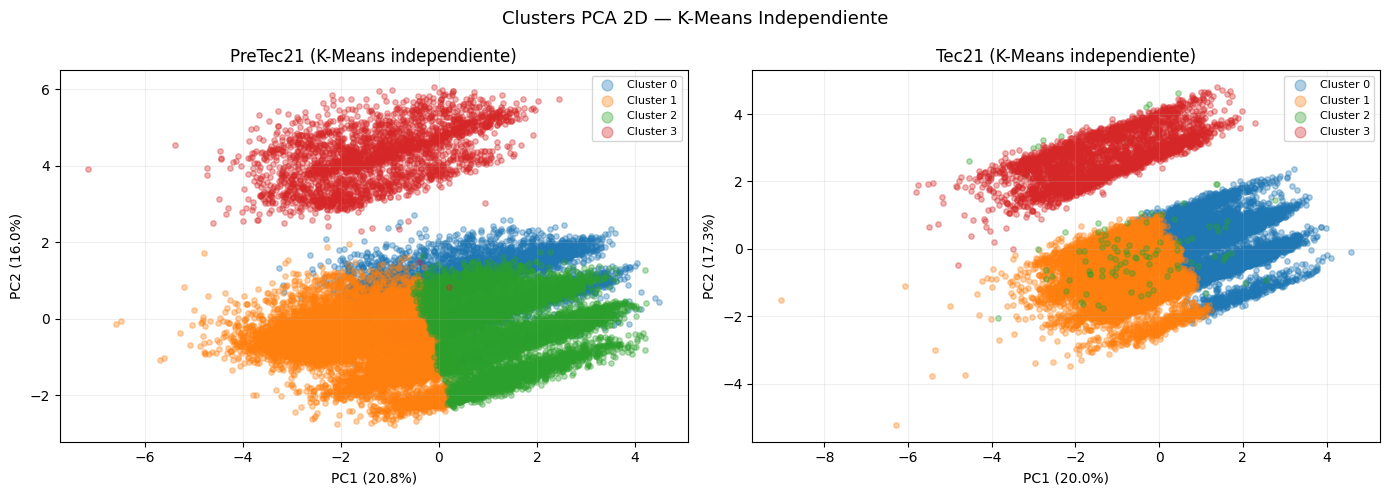

In [41]:
# ── PCA 2D separado para cada régimen ─────────────────────────────────────
pca_pre = PCA(n_components=2, random_state=SEED).fit(Xp_scaled)
pca_tec = PCA(n_components=2, random_state=SEED).fit(Xt_scaled)
Zp = pca_pre.transform(Xp_scaled)
Zt = pca_tec.transform(Xt_scaled)

COLORS = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for regime_name, Z, labels, pca_obj, ax in [
    ('PreTec21 (K-Means independiente)', Zp, km_pre.labels_, pca_pre, axes[0]),
    ('Tec21 (K-Means independiente)',    Zt, km_tec.labels_, pca_tec, axes[1])
]:
    for k in range(K_CLUSTERS):
        mask = labels == k
        ax.scatter(Z[mask,0], Z[mask,1], s=15, alpha=0.35, color=COLORS[k], label=f'Cluster {k}')
    ax.set_title(f'{regime_name}')
    ax.set_xlabel(f'PC1 ({pca_obj.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_obj.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(markerscale=2, fontsize=8); ax.grid(alpha=0.2)

plt.suptitle('Clusters PCA 2D — K-Means Independiente', fontsize=13)
plt.tight_layout()
plt.savefig(IMG_DIR / 'clusters_pca_independiente.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Match de Clusters entre Regímenes

Dado que los IDs de cluster no son directamente comparables (cada K-Means es independiente),
calculamos la **distancia coseno** entre los vectores de medias de cada cluster (normalizados).
El cluster con menor distancia es el candidato a match.

- Distancia coseno < 0.15 → **Match alto**
- 0.15 – 0.35 → **Match parcial**
- > 0.35 → **Sin match**

Matriz de distancias coseno (PreTec21 clusters × Tec21 clusters):
        Tec_C0  Tec_C1  Tec_C2  Tec_C3
Pre_C0  0.7940  0.9986  1.9374  1.1262
Pre_C1  1.7867  0.2473  0.6074  1.0115
Pre_C2  0.1415  1.6264  0.6293  1.3827
Pre_C3  1.3166  1.3797  1.1716  0.0299

═══ Resultado del Match ═══
Pre_C0 → Tec_C0  |  dist=0.7940  |  SIN MATCH
  PreTec21: n=9,498  dropout=0.070
  Tec21:    n=9,399  dropout=0.045
Pre_C1 → Tec_C1  |  dist=0.2473  |  PARCIAL
  PreTec21: n=21,311  dropout=0.122
  Tec21:    n=11,888  dropout=0.104
Pre_C2 → Tec_C0  |  dist=0.1415  |  ALTO
  PreTec21: n=19,557  dropout=0.058
  Tec21:    n=9,399  dropout=0.045
Pre_C3 → Tec_C3  |  dist=0.0299  |  ALTO
  PreTec21: n=2,644  dropout=0.109
  Tec21:    n=3,110  dropout=0.126


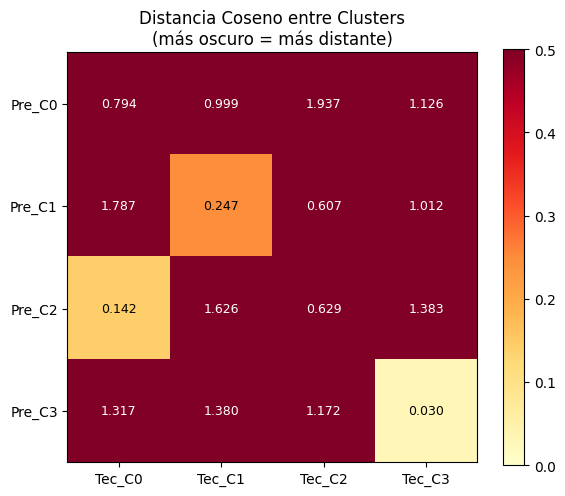

In [42]:
from scipy.spatial.distance import cosine as cosine_dist

# Calcular centroides en espacio de medias originales (estandarizadas con sus propios scalers)
centroids_pre = km_pre.cluster_centers_  # (K, n_features) en espacio estandarizado PreTec21
centroids_tec = km_tec.cluster_centers_  # (K, n_features) en espacio estandarizado Tec21

# Matriz de distancias coseno K×K
dist_matrix = np.zeros((K_CLUSTERS, K_CLUSTERS))
for i in range(K_CLUSTERS):
    for j in range(K_CLUSTERS):
        dist_matrix[i, j] = cosine_dist(centroids_pre[i], centroids_tec[j])

print('Matriz de distancias coseno (PreTec21 clusters × Tec21 clusters):')
df_dist = pd.DataFrame(dist_matrix,
                       index=[f'Pre_C{i}' for i in range(K_CLUSTERS)],
                       columns=[f'Tec_C{j}' for j in range(K_CLUSTERS)])
print(df_dist.round(4).to_string())

print('\n═══ Resultado del Match ═══')
matched_tec = set()
match_results = []
for i in range(K_CLUSTERS):
    j_best = int(np.argmin(dist_matrix[i]))
    d_best = dist_matrix[i, j_best]
    if d_best < MATCH_HIGH:
        quality = 'ALTO'
    elif d_best < MATCH_PARTIAL:
        quality = 'PARCIAL'
    else:
        quality = 'SIN MATCH'
    matched_tec.add(j_best)
    n_pre = (df_pre['cluster']==i).sum()
    n_tec = (df_tec['cluster']==j_best).sum()
    dr_pre = (df_pre[df_pre['cluster']==i][TARGET]==0).mean()
    dr_tec = (df_tec[df_tec['cluster']==j_best][TARGET]==0).mean()
    match_results.append({
        'Pre_Cluster': i, 'Tec_Cluster': j_best,
        'Cosine_dist': round(d_best, 4), 'Match': quality,
        'n_Pre': n_pre, 'n_Tec': n_tec,
        'dropout_Pre': round(dr_pre, 3), 'dropout_Tec': round(dr_tec, 3)
    })
    print(f'Pre_C{i} → Tec_C{j_best}  |  dist={d_best:.4f}  |  {quality}')
    print(f'  PreTec21: n={n_pre:,}  dropout={dr_pre:.3f}')
    print(f'  Tec21:    n={n_tec:,}  dropout={dr_tec:.3f}')

df_match = pd.DataFrame(match_results)

# Heatmap de distancias
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dist_matrix, cmap='YlOrRd', vmin=0, vmax=0.5)
ax.set_xticks(range(K_CLUSTERS)); ax.set_xticklabels([f'Tec_C{j}' for j in range(K_CLUSTERS)])
ax.set_yticks(range(K_CLUSTERS)); ax.set_yticklabels([f'Pre_C{i}' for i in range(K_CLUSTERS)])
for i in range(K_CLUSTERS):
    for j in range(K_CLUSTERS):
        ax.text(j, i, f'{dist_matrix[i,j]:.3f}', ha='center', va='center', fontsize=9,
                color='white' if dist_matrix[i,j] > 0.25 else 'black')
plt.colorbar(im, ax=ax)
ax.set_title('Distancia Coseno entre Clusters\n(más oscuro = más distante)')
plt.tight_layout()
plt.savefig(IMG_DIR / 'match_distance_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Features y Split para Modelos Supervisados

In [43]:
FEATURE_COLS_CANDIDATES = [
    'PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric',
    'general.math.eval', 'online.test', 'FTE', 'apoyo_financiero',
    'has_extracurriculars', 'has_physical', 'has_cultural', 'has_social',
    'first_gen_enc', 'educ_padres_max', 'socioec_enc', 'social_lag_enc',
    'age', 'is_male', 'estuvo_prepa_tec',
    'foreign_Yes: Foreigner', 'foreign_Yes: National',
    'school_enc', 'region_enc',
    'first_gen_present', 'parents_edu_present', 'took_admission_test',
    'has_socioeconomic_data', 'has_social_lag_data', 'has_zone_data',
]
EXCLUDE = {TARGET, 'cluster', 'generation', 'regime', 'educational.model'}
FEATURE_COLS = [c for c in FEATURE_COLS_CANDIDATES if c in df.columns and c not in EXCLUDE]
seen = set(); FEATURE_COLS = [c for c in FEATURE_COLS if c not in seen and not seen.add(c)]
print(f'Features para modelos supervisados ({len(FEATURE_COLS)}): {FEATURE_COLS}')

def make_split(df_regime, feature_cols, target=TARGET, seed=SEED):
    cols = [c for c in feature_cols if c in df_regime.columns]
    X    = df_regime[cols].values.astype(float)
    y    = df_regime[target].values.astype(int)
    imp  = SimpleImputer(strategy='median')
    X    = imp.fit_transform(X)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    return X_tr, X_te, y_tr, y_te, cols, imp

X_tr_pre, X_te_pre, y_tr_pre, y_te_pre, feat_pre, imp_pre = make_split(df_pre, FEATURE_COLS)
X_tr_tec, X_te_tec, y_tr_tec, y_te_tec, feat_tec, imp_tec = make_split(df_tec, FEATURE_COLS)
print(f'\nPreTec21  train: {X_tr_pre.shape}  test: {X_te_pre.shape}')
print(f'Tec21     train: {X_tr_tec.shape}  test: {X_te_tec.shape}')

Features para modelos supervisados (26): ['PNA', 'admission_test_norm', 'english.evaluation', 'admission.rubric', 'general.math.eval', 'online.test', 'FTE', 'apoyo_financiero', 'has_extracurriculars', 'first_gen_enc', 'educ_padres_max', 'socioec_enc', 'social_lag_enc', 'age', 'is_male', 'estuvo_prepa_tec', 'foreign_Yes: Foreigner', 'foreign_Yes: National', 'school_enc', 'region_enc', 'first_gen_present', 'parents_edu_present', 'took_admission_test', 'has_socioeconomic_data', 'has_social_lag_data', 'has_zone_data']

PreTec21  train: (42408, 26)  test: (10602, 26)
Tec21     train: (19605, 26)  test: (4902, 26)


## 9. Modelos Globales (PreTec21 → Tec21)

In [44]:
from sklearn.metrics import precision_recall_curve

def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name, feat_cols,
                   threshold=None, n_bootstrap=200, seed=SEED):
    model.fit(X_tr, y_tr)
    has_proba = hasattr(model, 'predict_proba')
    y_proba   = model.predict_proba(X_te)[:, 1] if has_proba else None
    if threshold is None and has_proba:
        skf_tmp = StratifiedKFold(n_splits=3, shuffle=True, random_state=seed)
        oof = np.zeros(len(X_tr))
        for tr_i, va_i in skf_tmp.split(X_tr, y_tr):
            model.fit(X_tr[tr_i], y_tr[tr_i])
            oof[va_i] = model.predict_proba(X_tr[va_i])[:, 1]
        model.fit(X_tr, y_tr)
        prec_oof, rec_oof, thr_oof = precision_recall_curve(y_tr, oof)
        f1_oof    = 2*prec_oof*rec_oof/(prec_oof+rec_oof+1e-8)
        threshold = float(thr_oof[np.argmax(f1_oof[:-1])])
    y_pred = (y_proba >= threshold).astype(int) if (threshold is not None and has_proba) \
             else model.predict(X_te)
    auc  = roc_auc_score(y_te, y_proba) if has_proba else 0.5
    rec  = recall_score(y_te, y_pred, zero_division=0)
    prec = precision_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    rng  = np.random.default_rng(seed)
    aucs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, len(y_te), len(y_te))
        if y_proba is not None and len(np.unique(y_te[idx])) > 1:
            aucs.append(roc_auc_score(y_te[idx], y_proba[idx]))
    ci_lo, ci_hi = (np.percentile(aucs, [2.5,97.5]) if aucs else (auc, auc))
    thr_str = f'{threshold:.2f}' if threshold is not None else 'N/A'
    result = dict(model=model_name, auc=auc, ci_lo=ci_lo, ci_hi=ci_hi,
                  recall=rec, precision=prec, f1=f1, threshold=threshold,
                  y_proba=y_proba, y_pred=y_pred, feat_cols=feat_cols)
    print(f'  {model_name:<28} AUC={auc:.3f} [{ci_lo:.3f},{ci_hi:.3f}]  '
          f'Recall={rec:.3f}  F1={f1:.3f}  thr={thr_str}')
    return result

SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results_global = []

print('═══ Regresión Logística ═══')
lr = LogisticRegression(class_weight='balanced', max_iter=2000, random_state=SEED, solver='lbfgs')
results_global.append(evaluate_model(lr, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec, 'LogisticRegression', feat_pre))

print('\n═══ Random Forest ═══')
rf = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                             class_weight='balanced', random_state=SEED, n_jobs=-1)
results_global.append(evaluate_model(rf, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec, 'RandomForest', feat_pre))
rf_global = rf

if XGB_AVAILABLE:
    print('\n═══ XGBoost ═══')
    spw = float((y_tr_pre==1).sum()) / max((y_tr_pre==0).sum(), 1)
    xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
                                   eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0)
    results_global.append(evaluate_model(xgb_model, X_tr_pre, X_te_tec, y_tr_pre, y_te_tec, 'XGBoost', feat_pre))
    xgb_global = xgb_model
else:
    xgb_global = None

print('\n═══ Modelos entrenados en Tec21 (self) ═══')
rf_tec_self = RandomForestClassifier(n_estimators=300, max_depth=8, min_samples_leaf=10,
                                      class_weight='balanced', random_state=SEED, n_jobs=-1)
res_tec_self = evaluate_model(rf_tec_self, X_tr_tec, X_te_tec, y_tr_tec, y_te_tec,
                               'RF_Tec21_self', feat_tec)
print('\n  (Comparar AUC RF_Tec21_self vs RandomForest cross-regime para medir degradación)')

═══ Regresión Logística ═══
  LogisticRegression           AUC=0.647 [0.622,0.670]  Recall=1.000  F1=0.955  thr=0.01

═══ Random Forest ═══
  RandomForest                 AUC=0.654 [0.628,0.677]  Recall=1.000  F1=0.955  thr=0.18

═══ XGBoost ═══
  XGBoost                      AUC=0.647 [0.623,0.671]  Recall=1.000  F1=0.955  thr=0.34

═══ Modelos entrenados en Tec21 (self) ═══
  RF_Tec21_self                AUC=0.676 [0.651,0.696]  Recall=0.997  F1=0.954  thr=0.30

  (Comparar AUC RF_Tec21_self vs RandomForest cross-regime para medir degradación)


## 10. SHAP Global — Invarianza de Importancias

In [45]:
if SHAP_AVAILABLE:
    def get_shap_matrix(shap_vals, class_idx=1):
        if isinstance(shap_vals, list):
            arr = np.array(shap_vals[class_idx] if len(shap_vals) > class_idx else shap_vals[0])
        else:
            arr = np.array(shap_vals)
        if arr.ndim == 3:
            arr = arr[:,:,class_idx]
        return arr

    explainer_rf = shap.TreeExplainer(rf_global)

    # SHAP en PreTec21 test
    raw_pre    = explainer_rf.shap_values(X_te_pre)
    shap_pre   = get_shap_matrix(raw_pre)
    mean_pre   = np.abs(shap_pre).mean(axis=0)

    # SHAP en Tec21 test
    raw_tec    = explainer_rf.shap_values(X_te_tec)
    shap_tec   = get_shap_matrix(raw_tec)
    mean_tec   = np.abs(shap_tec).mean(axis=0)

    inv_df = pd.DataFrame({
        'SHAP_PreTec21': pd.Series(mean_pre, index=feat_pre).round(5),
        'SHAP_Tec21'   : pd.Series(mean_tec, index=feat_pre).round(5),
        'Rank_Pre'     : pd.Series(mean_pre, index=feat_pre).rank(ascending=False),
        'Rank_Tec'     : pd.Series(mean_tec, index=feat_pre).rank(ascending=False),
    })
    inv_df['Delta_Rank'] = (inv_df['Rank_Tec'] - inv_df['Rank_Pre']).abs()
    inv_df['Delta_Pct']  = (inv_df['Delta_Rank'] / len(inv_df) * 100).round(1)
    inv_df['Estable']    = inv_df['Delta_Pct'] < 20
    inv_df = inv_df.sort_values('Rank_Pre')

    n_stable = inv_df['Estable'].sum()
    print(f'Variables estables (Δ < 20%): {n_stable} / {len(inv_df)}')
    print()
    print(inv_df.to_string())

    rho, p = spearmanr(inv_df['Rank_Pre'].values, inv_df['Rank_Tec'].values)
    print(f'\nCorrelación Spearman PreTec21 vs Tec21: ρ = {rho:.3f}  (p = {p:.4f})')
    verdict = '✓ Alta correlación — ranking invariante' if rho >= 0.7 \
              else '⚠ Baja correlación — ranking inestable'
    print(f'  {verdict}')
else:
    print('SHAP no disponible')

Variables estables (Δ < 20%): 25 / 26

                        SHAP_PreTec21  SHAP_Tec21  Rank_Pre  Rank_Tec  Delta_Rank  Delta_Pct  Estable
general.math.eval             0.04084     0.04557       1.0       1.0         0.0        0.0     True
apoyo_financiero              0.03431     0.03751       2.0       2.0         0.0        0.0     True
PNA                           0.03091     0.03273       3.0       3.0         0.0        0.0     True
FTE                           0.02321     0.02521       4.0       5.0         1.0        3.8     True
english.evaluation            0.02143     0.02747       5.0       4.0         1.0        3.8     True
admission.rubric              0.01478     0.01772       6.0       6.0         0.0        0.0     True
admission_test_norm           0.01120     0.01075       7.0       8.0         1.0        3.8     True
estuvo_prepa_tec              0.01042     0.01015       8.0       9.0         1.0        3.8     True
age                           0.01013     0

## 11. Modelos RF y SHAP por Cluster (K-Means Independiente)

In [46]:
def train_rf_cluster_shap(df_regime, feat_cols, cluster_id, regime_name, seed=SEED):
    sub  = df_regime[df_regime['cluster']==cluster_id].copy()
    cols = [c for c in feat_cols if c in sub.columns and sub[c].std() > 0]
    if len(cols) < 3:
        print(f'  Cluster {cluster_id} [{regime_name}]: pocas features — omitido')
        return None
    X  = SimpleImputer(strategy='median').fit_transform(sub[cols].values.astype(float))
    y  = sub[TARGET].values.astype(int)
    if len(np.unique(y)) < 2 or (y==0).sum() < 5:
        print(f'  Cluster {cluster_id} [{regime_name}]: clases insuficientes — omitido')
        return None
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=y)
    rf_c = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5,
                                  class_weight='balanced', random_state=seed, n_jobs=-1)
    rf_c.fit(X_tr, y_tr)
    y_proba = rf_c.predict_proba(X_te)[:, 1]
    auc = roc_auc_score(y_te, y_proba) if len(np.unique(y_te)) > 1 else 0.5
    rec = recall_score(y_te, (y_proba >= 0.5).astype(int), zero_division=0)
    f1  = f1_score(y_te, (y_proba >= 0.5).astype(int), zero_division=0)
    # SHAP
    shap_top = None
    if SHAP_AVAILABLE:
        exp = shap.TreeExplainer(rf_c)
        sv  = exp.shap_values(X_te)
        if isinstance(sv, list): sv = np.array(sv[1])
        else: sv = np.array(sv)
        if sv.ndim == 3: sv = sv[:,:,1]
        mean_sv = np.abs(sv).mean(axis=0)
        shap_top = pd.Series(mean_sv, index=cols).sort_values(ascending=False)
    fi = pd.Series(rf_c.feature_importances_, index=cols).sort_values(ascending=False)
    print(f'  Cluster {cluster_id} [{regime_name:>8}] n={len(sub):>5}  AUC={auc:.3f}  Recall={rec:.3f}  F1={f1:.3f}')
    return dict(cluster=cluster_id, regime=regime_name, n=len(sub),
                auc=auc, recall=rec, f1=f1,
                model=rf_c, feat_importance=fi, shap_top=shap_top, feat_cols=cols)

print('═══ RF por Cluster (K-Means Independiente) ═══\n')
cluster_results = []
for regime_name, df_regime in [('PreTec21', df_pre), ('Tec21', df_tec)]:
    print(f'--- {regime_name} ---')
    for k in sorted(df_regime['cluster'].unique()):
        res = train_rf_cluster_shap(df_regime, FEATURE_COLS, k, regime_name)
        if res: cluster_results.append(res)
    print()

print(f'✓ Modelos por cluster: {len(cluster_results)}')

═══ RF por Cluster (K-Means Independiente) ═══

--- PreTec21 ---
  Cluster 0 [PreTec21] n= 9498  AUC=0.648  Recall=0.701  F1=0.806
  Cluster 1 [PreTec21] n=21311  AUC=0.627  Recall=0.720  F1=0.802
  Cluster 2 [PreTec21] n=19557  AUC=0.631  Recall=0.765  F1=0.849
  Cluster 3 [PreTec21] n= 2644  AUC=0.623  Recall=0.815  F1=0.854

--- Tec21 ---
  Cluster 0 [   Tec21] n= 9399  AUC=0.579  Recall=0.913  F1=0.936
  Cluster 1 [   Tec21] n=11888  AUC=0.577  Recall=0.752  F1=0.821
  Cluster 2 [   Tec21] n=  110  AUC=0.438  Recall=0.167  F1=0.182
  Cluster 3 [   Tec21] n= 3110  AUC=0.650  Recall=0.748  F1=0.818

✓ Modelos por cluster: 8


In [47]:
df_cm = pd.DataFrame([{k:v for k,v in r.items() if k not in ('model','feat_importance','shap_top','feat_cols')}
                       for r in cluster_results]).round(3)
print('═══ Métricas por Cluster ═══')
print(df_cm.to_string(index=False))

═══ Métricas por Cluster ═══
 cluster   regime     n   auc  recall    f1
       0 PreTec21  9498 0.648   0.701 0.806
       1 PreTec21 21311 0.627   0.720 0.802
       2 PreTec21 19557 0.631   0.765 0.849
       3 PreTec21  2644 0.623   0.815 0.854
       0    Tec21  9399 0.579   0.913 0.936
       1    Tec21 11888 0.577   0.752 0.821
       2    Tec21   110 0.438   0.167 0.182
       3    Tec21  3110 0.650   0.748 0.818


In [48]:
if SHAP_AVAILABLE:
    print('═══ SHAP Top-5 por Cluster ═══\n')
    for r in cluster_results:
        if r['shap_top'] is None: continue
        print(f"Cluster {r['cluster']} [{r['regime']:>8}] (n={r['n']:,}, dropout_rate inferred from metrics):")
        for feat, val in r['shap_top'].head(5).items():
            print(f"  {feat:<30} {val:.5f}")
        print()

═══ SHAP Top-5 por Cluster ═══

Cluster 0 [PreTec21] (n=9,498, dropout_rate inferred from metrics):
  apoyo_financiero               0.04272
  general.math.eval              0.03662
  PNA                            0.03436
  admission.rubric               0.02638
  english.evaluation             0.01259

Cluster 1 [PreTec21] (n=21,311, dropout_rate inferred from metrics):
  general.math.eval              0.03273
  FTE                            0.02865
  english.evaluation             0.02711
  PNA                            0.01332
  age                            0.01259

Cluster 2 [PreTec21] (n=19,557, dropout_rate inferred from metrics):
  general.math.eval              0.02753
  apoyo_financiero               0.01977
  admission_test_norm            0.01887
  PNA                            0.01529
  estuvo_prepa_tec               0.01293

Cluster 3 [PreTec21] (n=2,644, dropout_rate inferred from metrics):
  apoyo_financiero               0.05722
  general.math.eval              0.

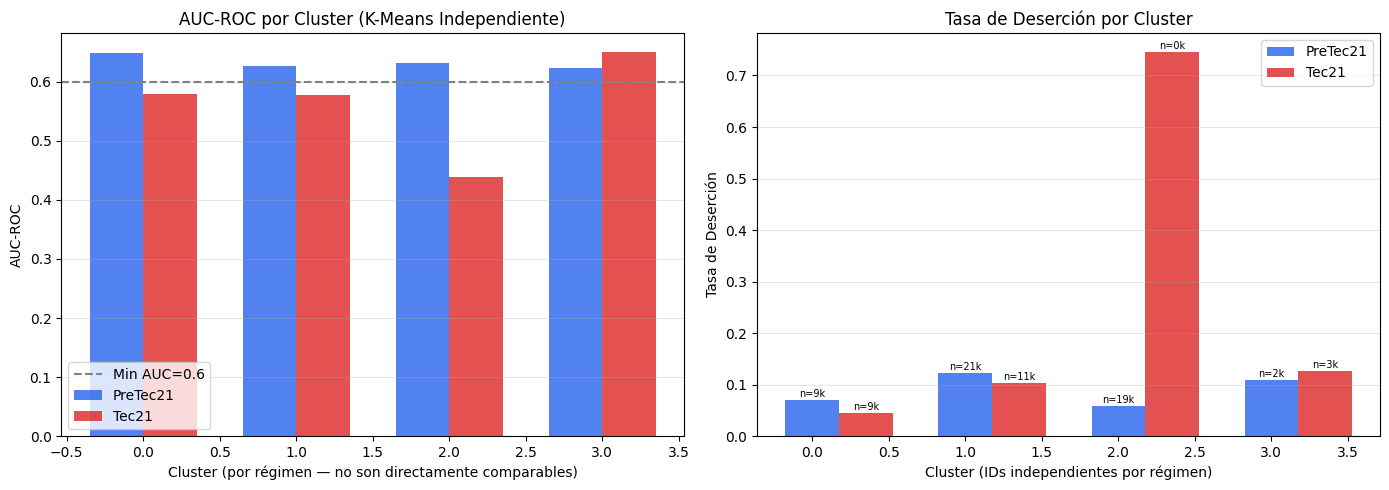

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC por cluster y régimen
ax = axes[0]
for i, (regime_name, color) in enumerate([('PreTec21','#2563eb'),('Tec21','#dc2626')]):
    sub = df_cm[df_cm['regime']==regime_name]
    ax.bar(sub['cluster'] + i*0.35 - 0.175, sub['auc'], 0.35,
           label=regime_name, color=color, alpha=0.8)
ax.axhline(MIN_AUC, ls='--', color='gray', label=f'Min AUC={MIN_AUC}')
ax.set_xlabel('Cluster (por régimen — no son directamente comparables)')
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC-ROC por Cluster (K-Means Independiente)')
ax.legend(); ax.grid(axis='y', alpha=0.3)

# Dropout rate por cluster
ax2 = axes[1]
for regime_name, df_regime, color in [('PreTec21', df_pre, '#2563eb'), ('Tec21', df_tec, '#dc2626')]:
    clusters = sorted(df_regime['cluster'].unique())
    drs = [(df_regime[df_regime['cluster']==c][TARGET]==0).mean() for c in clusters]
    ns  = [len(df_regime[df_regime['cluster']==c]) for c in clusters]
    bars = ax2.bar([c + (0 if regime_name=='PreTec21' else 0.35) for c in clusters],
                   drs, 0.35, label=regime_name, color=color, alpha=0.8)
    for bar, n in zip(bars, ns):
        ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                 f'n={n//1000}k', ha='center', va='bottom', fontsize=7)
ax2.set_xlabel('Cluster (IDs independientes por régimen)')
ax2.set_ylabel('Tasa de Deserción')
ax2.set_title('Tasa de Deserción por Cluster')
ax2.legend(); ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(IMG_DIR / 'cluster_metrics_independiente.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Análisis de Invarianza (SHAP PreTec21 → Tec21)

In [50]:
# Comparar SHAP top features entre clusters con match
if SHAP_AVAILABLE and len(df_match) > 0:
    print('═══ Invarianza de SHAP en Clusters con Match ═══\n')
    for _, row in df_match.iterrows():
        pre_c = int(row['Pre_Cluster'])
        tec_c = int(row['Tec_Cluster'])
        quality = row['Match']

        r_pre = next((r for r in cluster_results if r['regime']=='PreTec21' and r['cluster']==pre_c), None)
        r_tec = next((r for r in cluster_results if r['regime']=='Tec21' and r['cluster']==tec_c), None)

        if r_pre is None or r_tec is None or r_pre['shap_top'] is None or r_tec['shap_top'] is None:
            print(f'  Pre_C{pre_c} → Tec_C{tec_c}: datos insuficientes para comparación SHAP')
            continue

        # Spearman en features comunes
        feats_common = list(set(r_pre['feat_cols']) & set(r_tec['feat_cols']))
        v_pre = [float(r_pre['shap_top'].get(f, 0)) for f in feats_common]
        v_tec = [float(r_tec['shap_top'].get(f, 0)) for f in feats_common]

        if len(feats_common) < 4:
            print(f'  Pre_C{pre_c} → Tec_C{tec_c}: pocas features comunes')
            continue

        rho, pval = spearmanr(v_pre, v_tec)
        print(f'Pre_C{pre_c} → Tec_C{tec_c}  |  match={quality}  |  Spearman ρ={rho:.3f}  (p={pval:.3f})')

        # Top-5 comparado
        top5_pre = r_pre['shap_top'].head(5).index.tolist()
        top5_tec = r_tec['shap_top'].head(5).index.tolist()
        common_top = set(top5_pre) & set(top5_tec)
        print(f'  Top-5 PreTec21: {top5_pre}')
        print(f'  Top-5 Tec21:    {top5_tec}')
        print(f'  Features en común (top-5): {len(common_top)}/5 → {sorted(common_top)}')
        print()
else:
    print('SHAP no disponible o sin resultados de match')

═══ Invarianza de SHAP en Clusters con Match ═══

Pre_C0 → Tec_C0  |  match=SIN MATCH  |  Spearman ρ=0.863  (p=0.000)
  Top-5 PreTec21: ['apoyo_financiero', 'general.math.eval', 'PNA', 'admission.rubric', 'english.evaluation']
  Top-5 Tec21:    ['apoyo_financiero', 'region_enc', 'general.math.eval', 'admission.rubric', 'admission_test_norm']
  Features en común (top-5): 3/5 → ['admission.rubric', 'apoyo_financiero', 'general.math.eval']

Pre_C1 → Tec_C1  |  match=PARCIAL  |  Spearman ρ=0.571  (p=0.013)
  Top-5 PreTec21: ['general.math.eval', 'FTE', 'english.evaluation', 'PNA', 'age']
  Top-5 Tec21:    ['PNA', 'admission.rubric', 'general.math.eval', 'age', 'FTE']
  Features en común (top-5): 4/5 → ['FTE', 'PNA', 'age', 'general.math.eval']

Pre_C2 → Tec_C0  |  match=ALTO  |  Spearman ρ=0.743  (p=0.000)
  Top-5 PreTec21: ['general.math.eval', 'apoyo_financiero', 'admission_test_norm', 'PNA', 'estuvo_prepa_tec']
  Top-5 Tec21:    ['apoyo_financiero', 'region_enc', 'general.math.eval', 'a

## 13. Resumen Final

In [51]:
print('='*65)
print('RESUMEN — K-Means Independiente (Notebook 02b)')
print('='*65)

print('\n📊 CLUSTERING INDEPENDIENTE')
print(f'  Silhouette PreTec21: {sil_pre:.3f}  {"✓" if sil_pre>=MIN_SILHOUETTE else "✗"}')
print(f'  Silhouette Tec21   : {sil_tec:.3f}  {"✓" if sil_tec>=MIN_SILHOUETTE else "✗"}')
print(f'  DB PreTec21: {db_pre:.3f}  {"✓" if db_pre<=MAX_DB else "✗"}')
print(f'  DB Tec21   : {db_tec:.3f}  {"✓" if db_tec<=MAX_DB else "✗"}')

print('\n🔗 MATCH DE CLUSTERS (distancia coseno)')
print(df_match[['Pre_Cluster','Tec_Cluster','Cosine_dist','Match','n_Pre','n_Tec','dropout_Pre','dropout_Tec']].to_string(index=False))

print('\n🤖 MODELOS GLOBALES (PreTec21 → Tec21)')
for r in results_global:
    ok = '✓' if r['auc'] >= MIN_AUC else '✗'
    print(f'  {ok} {r["model"]:<28} AUC={r["auc"]:.3f}  Recall={r["recall"]:.3f}  F1={r["f1"]:.3f}')
print(f'  (ref) RF_Tec21_self              AUC={res_tec_self["auc"]:.3f}  (baseline self-trained)')

print('\n🔍 MODELOS POR CLUSTER')
print(df_cm.to_string(index=False))

if SHAP_AVAILABLE:
    pct_stable = inv_df['Estable'].mean() * 100
    print(f'\n📈 INVARIANZA SHAP GLOBAL')
    print(f'  Variables estables (Δ rango < 20%): {pct_stable:.0f}%')
    print(f'  Correlación Spearman: ρ = {rho:.3f}')
    verdict = '→ INVARIANTE' if rho >= 0.7 and pct_stable >= 60 else '→ MUTA entre regímenes'
    print(f'  {verdict}')

print('\n' + '='*65)

RESUMEN — K-Means Independiente (Notebook 02b)

📊 CLUSTERING INDEPENDIENTE
  Silhouette PreTec21: 0.177  ✗
  Silhouette Tec21   : 0.204  ✗
  DB PreTec21: 1.683  ✗
  DB Tec21   : 1.361  ✓

🔗 MATCH DE CLUSTERS (distancia coseno)
 Pre_Cluster  Tec_Cluster  Cosine_dist     Match  n_Pre  n_Tec  dropout_Pre  dropout_Tec
           0            0       0.7940 SIN MATCH   9498   9399        0.070        0.045
           1            1       0.2473   PARCIAL  21311  11888        0.122        0.104
           2            0       0.1415      ALTO  19557   9399        0.058        0.045
           3            3       0.0299      ALTO   2644   3110        0.109        0.126

🤖 MODELOS GLOBALES (PreTec21 → Tec21)
  ✓ LogisticRegression           AUC=0.647  Recall=1.000  F1=0.955
  ✓ RandomForest                 AUC=0.654  Recall=1.000  F1=0.955
  ✓ XGBoost                      AUC=0.647  Recall=1.000  F1=0.955
  (ref) RF_Tec21_self              AUC=0.676  (baseline self-trained)

🔍 MODELOS POR CLU